In [1]:
import random
import gdown
import zipfile
import os
import shutil
from PIL import Image
from tqdm import tqdm
import hashlib
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import image

## Loading Images

In [2]:
# Google Drive link
file_url = "https://drive.google.com/file/d/1oUX991nPh4330ZzbXzBKKOAswhx75BtV/view?usp=sharing"

# Output filename
output = "dataset.zip"


In [3]:
# Download directly from Google Drive
gdown.download(file_url, output, quiet = False, fuzzy = True)

# Extract the zip file
extract_dir = "/content/images"
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

Downloading...
From (original): https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV
From (redirected): https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV&confirm=t&uuid=cef55809-1a1e-439a-8e11-2e745592fb7f
To: /content/dataset.zip
100%|██████████| 9.26G/9.26G [02:02<00:00, 75.8MB/s]


In [4]:
print("Total files extracted:", sum(len(files) for _, _, files in os.walk("/content/images")))
print("Sample files:", os.listdir("/content/images")[:10])

Total files extracted: 34731
Sample files: ['images']


In [5]:
image_dir = f"{extract_dir}/images/"

In [6]:
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg') or f.endswith('.png')]

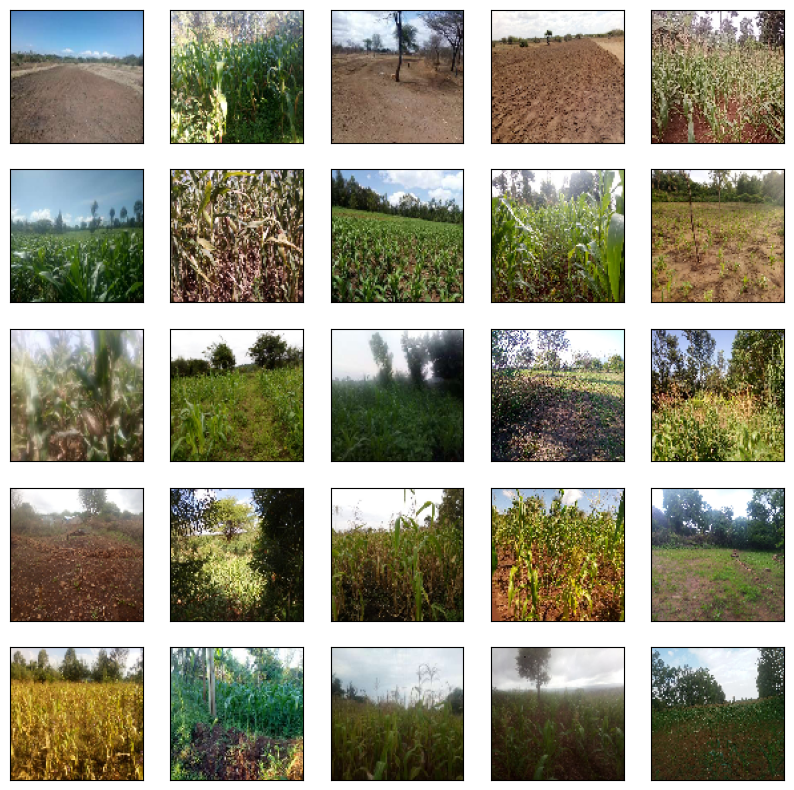

In [15]:
plt.figure(figsize = (10, 10))
# Select a subset of image files to display
sample_files = random.sample(image_files, min(25, len(image_files)))
for i, file in enumerate(sample_files):
  img_path = os.path.join(image_dir, file)
  img = image.load_img(img_path, target_size = (100, 100))  # Adjust the target size as needed
  plt.subplot(5, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(img)
plt.show()

In [10]:
input_dir = "/content/images"

In [11]:
# pick first 10 image paths
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [12]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


Streaming output truncated to the last 5000 lines.
9e46ef0fcb3648c756a70c4f4a9302248967729e.jpg → (320, 240)
8d91a7fa60a11fee52ce98f74c639fa01184f3f2.jpg → (640, 480)
c899ee3ffcacd079e01cf52cc048dd859c4d2d41.jpg → (3952, 1872)
01732555ffbc41356ab3faf5d2f5428860ce58a2.jpg → (640, 480)
71f502dc3cca37e1e296bb7cabdc855cab0719ca.jpg → (640, 480)
8fbc7f523307aea77efde6995d505e2abdadbf7a.jpg → (320, 240)
38f92608587f6798d79ba16a51210d7fa38cddec.jpg → (320, 240)
b3d58151f61ed9a88100bacf222811b8ed8b3f54.jpg → (640, 480)
ca333663bd8e0767b5392792ab01acb88ef36d5d.jpg → (640, 480)
4387482892568a714262353f6b9338903d83341b.jpg → (320, 240)
4bdfedb95c3e79f437820dc1c22dbb46c10c0a59.jpg → (320, 240)
9fedf2b2629abbe49dc412df9db1308a18c11bbc.jpg → (640, 480)
6f864de8b9d2a80337afefab14d8b8ee5bca3d1b.jpg → (320, 240)
15dcd5d9e99c0377de4a368c8042cb57065aceb8.jpg → (3264, 2448)
04a45b8b841ceae0cd72712be104e5c1214cee60.jpg → (3264, 2448)
4c125736f6a72d4c3f294628a38a542e2514a27b.jpg → (640, 480)
cc4ca1abeb762f0

In [13]:
image_data = []
for img_path in image_files:
    try:
        with Image.open(img_path) as img:
            image_data.append({'filename': os.path.basename(img_path), 'dimensions': img.size})
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

image_df = pd.DataFrame(image_data)
display(image_df.head())

,filename,dimensions
0,435fc81ba00cfb2dcce585b6e98702fbffee2997.jpg,"(640, 480)"
1,88418faead1205fb141a3d63a5b268b804784568.jpg,"(320, 240)"
2,6074cffd7f8dc9f96ac141d5633bfbd49677b732.jpg,"(640, 480)"
3,0e918c211e5b966421156f7847825186f2ea7daa.jpg,"(320, 240)"
4,6d7f357c0f0eafc6f37774666db6e80f5a3fa3a0.jpg,"(640, 480)"


In [14]:
dimension_counts = image_df.groupby('dimensions').size().reset_index(name='count')
display(dimension_counts)

,dimensions,count
0,"(102, 204)",1
1,"(117, 260)",3
2,"(120, 120)",2
3,"(120, 160)",5
4,"(121, 161)",1
5,"(121, 162)",2
6,"(122, 162)",4
7,"(150, 200)",2
8,"(153, 204)",381
9,"(160, 120)",7


In [15]:
# Target Size
size = (100, 100)

In [16]:
for img_path in tqdm(image_files, desc = "Resizing images"):
    try:
        with Image.open(img_path).convert("RGB") as img:
            img = img.resize(size, Image.Resampling.LANCZOS)
            img.save(img_path, "JPEG")
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(img_path)}: {e}")

Resizing images: 100%|██████████| 34731/34731 [23:37<00:00, 24.50it/s]


In [17]:
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [18]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


Streaming output truncated to the last 5000 lines.
9e46ef0fcb3648c756a70c4f4a9302248967729e.jpg → (100, 100)
8d91a7fa60a11fee52ce98f74c639fa01184f3f2.jpg → (100, 100)
c899ee3ffcacd079e01cf52cc048dd859c4d2d41.jpg → (100, 100)
01732555ffbc41356ab3faf5d2f5428860ce58a2.jpg → (100, 100)
71f502dc3cca37e1e296bb7cabdc855cab0719ca.jpg → (100, 100)
8fbc7f523307aea77efde6995d505e2abdadbf7a.jpg → (100, 100)
38f92608587f6798d79ba16a51210d7fa38cddec.jpg → (100, 100)
b3d58151f61ed9a88100bacf222811b8ed8b3f54.jpg → (100, 100)
ca333663bd8e0767b5392792ab01acb88ef36d5d.jpg → (100, 100)
4387482892568a714262353f6b9338903d83341b.jpg → (100, 100)
4bdfedb95c3e79f437820dc1c22dbb46c10c0a59.jpg → (100, 100)
9fedf2b2629abbe49dc412df9db1308a18c11bbc.jpg → (100, 100)
6f864de8b9d2a80337afefab14d8b8ee5bca3d1b.jpg → (100, 100)
15dcd5d9e99c0377de4a368c8042cb57065aceb8.jpg → (100, 100)
04a45b8b841ceae0cd72712be104e5c1214cee60.jpg → (100, 100)
4c125736f6a72d4c3f294628a38a542e2514a27b.jpg → (100, 100)
cc4ca1abeb762f0bc69ab

In [19]:
seen = set()
duplicates = []

for path in tqdm(image_files, desc = "Checking for duplicates"):
    try:
        with open(path, "rb") as f:
            hash_val = hashlib.md5(f.read()).hexdigest()
        if hash_val in seen:
            os.remove(path)
            duplicates.append(path)
        else:
            seen.add(hash_val)
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(path)}: {e}")

print(f"✅ Removed {len(duplicates)} duplicate images")

Checking for duplicates: 100%|██████████| 34731/34731 [00:01<00:00, 34368.73it/s]

✅ Removed 0 duplicate images


In [20]:
bad_files = []

for path in tqdm(image_files, desc="Checking for corrupted images"):
    try:
        img = Image.open(path)
        img.verify()  # check if corrupted
    except Exception:
        bad_files.append(path)
        os.remove(path)

print(f"✅ Removed {len(bad_files)} corrupted images")

Checking for corrupted images: 100%|██████████| 34731/34731 [00:02<00:00, 15309.10it/s]

✅ Removed 0 corrupted images


## Loading Train Dataset

In [22]:
import gspread
from google.auth import default
from google.colab import auth
auth.authenticate_user()

# Autheticate and create the client
creds, _ = default()
gc = gspread.authorize(creds)

# Open the spreadsheet and select the worksheet
spreadsheet_url = 'https://docs.google.com/spreadsheets/d/1CkALzjyKZX-BeL1JpxStVTbhd_hdJJL-BlM5u7ikl2w/edit?gid=623294923#gid=623294923'
sh = gc.open_by_url(spreadsheet_url)
worksheet = sh.worksheet('Train') # Replace 'Sheet1' with the actual sheet name

# Get all values from the worksheet
data = worksheet.get_all_values()

# Convert to a pandas DataFrame
train = pd.DataFrame(data[1:], columns=data[0])

In [23]:
train.head()

,ID,damage,filename
0,ID_UBHORS,WD,d036341be8d6cd59851cb80bcc9a70cc9fbdba30.jpg
1,ID_9DSOLZ,G,9ea16180c50d0cd539897eefbfe585314e50a56b.jpg
2,ID_JHLM0G,G,b6b564844041bc68774a553eaf43d61654657dd9.jpg
3,ID_ATREIJ,DR,62262859f0cd411aaf484082ed3ef0b625bc452a.jpg
4,ID_L2GAD6,G,03b6e2a8ace7cb611eccba289f3c83d9bd497584.jpg


In [28]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test = train_test_split(train, test_size = 0.2, random_state = 42)

In [38]:
len(X_train)

20854

In [39]:
len(X_test)

5214

# always use the path not the list

## Model Building

In [33]:
from fastai.vision.all import *
set_seed(42)

In [40]:
# Combine them to create a single source DataFrame with known split indices
df_combined = pd.concat([X_train, X_test], ignore_index=True)

In [41]:
# Get the indices for validation set (i.e., where test_df starts)
valid_idx = list(range(len(X_train), len(df_combined)))

In [42]:
train.head(2)

,ID,damage,filename
0,ID_UBHORS,WD,d036341be8d6cd59851cb80bcc9a70cc9fbdba30.jpg
1,ID_9DSOLZ,G,9ea16180c50d0cd539897eefbfe585314e50a56b.jpg


In [45]:
# Define DataBlock with IndexSplitter to respect your manual split
plant_db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=lambda x: Path(image_dir) / x['filename'],    # image directory
    get_y=lambda x: x['damage'],                        # target variable
    splitter=IndexSplitter(valid_idx),
    batch_tfms=aug_transforms()
)

In [46]:
# Create DataLoaders from the combined df
dls = plant_db.dataloaders(df_combined, bs=32)

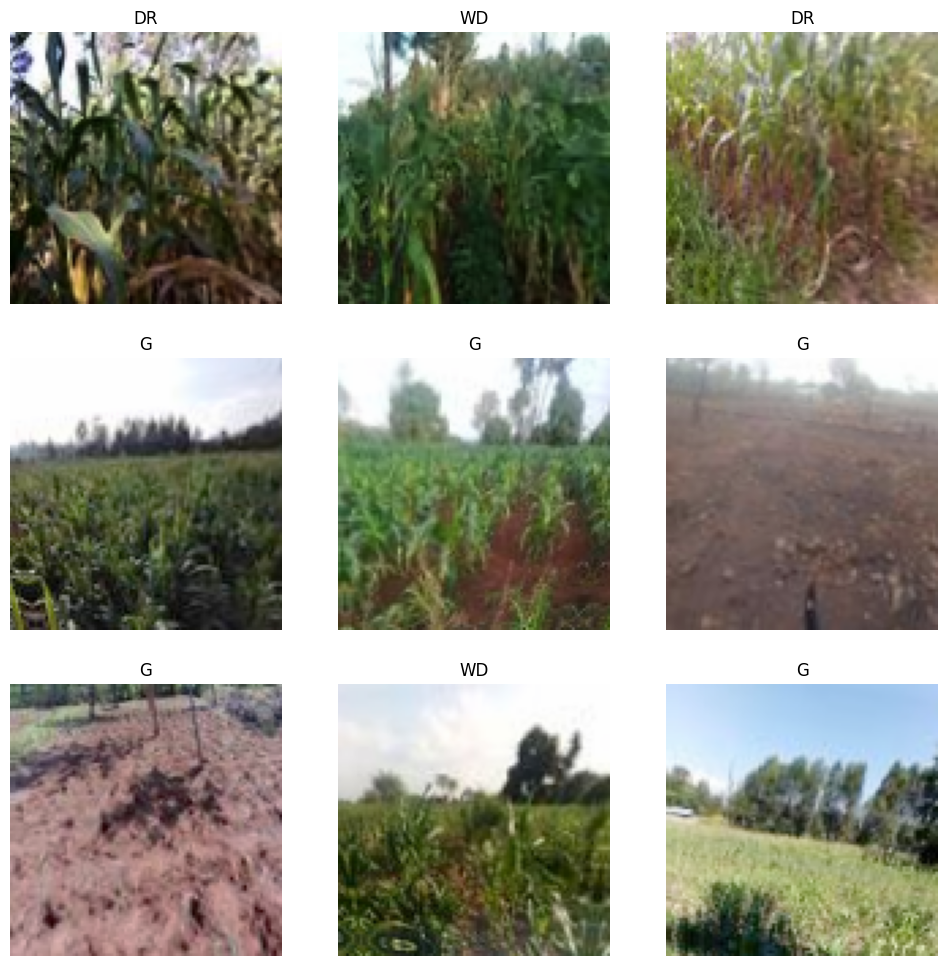

In [47]:
# Show a batch
dls.show_batch(max_n=9, figsize=(12,12))

In [48]:
# Create learner
learn = vision_learner(dls, resnet34, metrics=[accuracy, error_rate])

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 107MB/s]


In [ ]:
# Train the model
learn.fine_tune(5)

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.138967,1.050933,0.527810,0.472190,32:36


epoch,train_loss,valid_loss,accuracy,error_rate,time


In [ ]:
# Interpret results
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(9, figsize=(15,10))

In [ ]:
# Save model
learn.export('crop_damage_classifier.pkl')

In [ ]:
# Create test DataLoader (assuming test_df is untouched during training)
test_dl = dls.test_dl(X_test)

# Get predictions
preds, _ = learn.get_preds(dl=test_dl)

# Get predicted classes
pred_classes = preds.argmax(dim=1)

# Map to class labels
pred_labels = [dls.vocab[i] for i in pred_classes]

# Add to test_df for analysis
test_df = test_df.copy()
test_df['predicted_label'] = pred_labels

# Calculate accuracy manually if you have true labels
from sklearn.metrics import accuracy_score
acc = accuracy_score(test_df['data_type'], test_df['predicted_label'])
print(f"Test Accuracy: {acc:.4f}")